# XGBoost Model

The same workflow from the previous model notebooks will be applied here using XGBoost instead of logistic regression or random forest, i.e. build and evaluate baseline model with default parameters, then apply cross validation and hyperparameter grid search to improve performance and handle overfitting risks. 

After final model training and selection, the model will be evaluated on the test set, while also assessing feature importance and applying a threshold sweep. 

In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier 

from src.data_loader import load_features
from src.preprocessing import clean_data, encode_categoricals
from src.split import patient_split, get_features_and_target
from src.evaluate import compute_metrics, evaluate_model

In [2]:
df = load_features()
df = clean_data(df)

train_df, test_df = patient_split(df)

X_train, y_train, ids_train = get_features_and_target(train_df)
X_test, y_test, ids_test = get_features_and_target(test_df)

X_train, X_test = encode_categoricals(X_train, X_test)

groups_train = ids_train['patient_nbr'] # will be used for group k-fold cross-validation

Loaded 101,766 rows, 54 columns.
Unique patients: 71,518

Columns with missing values:
race      2367
gender       3

Readmitted-within-30-days rate: 11.16%

  Dropped 2,423 rows with death/hospice discharge disposition.
  Dropped 3 rows with missing/invalid gender.
  Filled 2,320 missing race values with 'Unknown'.

Raw data: 101,766 encounters; Cleaned data: 99,340 encounters (2,426 dropped total).

Total encounters: 99,340 | Train: 79,462 (80.0%) | Test: 19,878 (20.0%)
Readmit rate - Full: 11.39% | Train: 11.36% | Test: 11.51%

Encoding 33 categorical columns: ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_p

### Baseline XGBoost Model

Unlike logistic regression and random forest that have simple class imbalance handling built-in (i.e. `class_weight=balanced`) XGBooost does not. It alternatively has `scale_pos_weight`, which must be defined manually. The most common approach for determining the value for `scale_pos_weight` is taking the sum of negative target class divided by sum of the positive target class.  

In [3]:
# handle class imbalance by setting scale_pos_weight to the ratio of negative to positive samples 
# (a standard approach for XGBoost); done only on the training set to avoid data leakage
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_baseline = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
)
xgb_baseline.fit(X_train, y_train)

scale_pos_weight: 7.80


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


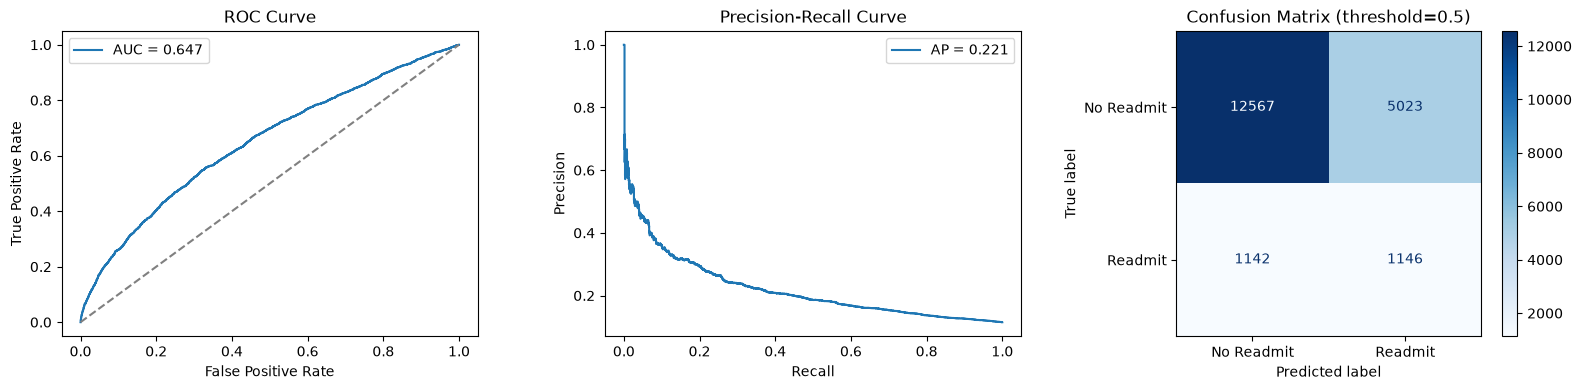

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,0.814756,0.415413,0.732161,0.259015,0.729781,0.382332,0.5
test,0.647440,0.221381,0.689858,0.185768,0.500874,0.271018,0.5


In [4]:
# Evaluate the baseline model
y_train_pred_proba = xgb_baseline.predict_proba(X_train)
y_test_pred_proba = xgb_baseline.predict_proba(X_test)

train_metrics = compute_metrics(y_train, y_train_pred_proba)
test_metrics = evaluate_model(y_test, y_test_pred_proba)  # runs plots + returns dict

pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])

### Observations on the Baseline XGBoost Model

Initial Results:

- minor overfitting evident in the gap between train and test evaluation metrics. 
- PR-AUC = 0.221 is fair; performace is worse than the logistic regression model and tuned random forest model.
- recall of ~0.50; catches about half of the positive class. 

### Hyperparameter Tuning

In the random forest model, a standard grid search was performed and manually modified through multiple iterations based on results. For XGBoost, a slightly modified workflow will be applied. A random grid search was performed, which allows us to search through a sample of a much larger parameter space more efficiently than a standard grid search of a fixed discrete parameter grid. While this saves on computational cost and reduces runtime, the grid search is not guaranteed to find the best configuration, but will find a configuration close to optimal. With 6 hyperparemeters and 4-6 values for each, this yields a total of 9,600 configurations. `n_iter` was set to 60, meaning 60 random configurations were tested.

The finalized hyperparameter grid was determined after multiple iterations of smaller grid searches. For instance, previous iterations found that increasing `min_child_weight` significantly increased cv_score results, hence why the finalized hyperparameter grid search has a much larger range of values for `min_child_weight` compared to other hyperparameters. 

In [12]:
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search for hyperparameter tuning (4*5*5*4*4*6 = 9600 combinations)
param_distributions = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 300, 500, 700, 900],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 5, 10, 15, 25, 30],
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=param_distributions,
    n_iter=60,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    verbose=1,
    return_train_score=True # return train score for analysis of overfitting
)

xgb_random_search.fit(X_train, y_train, groups=groups_train)

print("Best params (random search):", xgb_random_search.best_params_)
print("Best CV PR-AUC (random search):", xgb_random_search.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params (random search): {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 15, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV PR-AUC (random search): 0.22515217856629066


### Final Model Configuration Selection

The top 10 best performing configurations from the grid search will be looked at individually and the configuration with the smallest gap will be selected. For more information on this design decision address `README.md` under "Key Design Decisions".

In [13]:
results_df = pd.DataFrame(xgb_random_search.cv_results_) 
results_df['gap'] = results_df['mean_train_score'] - results_df['mean_test_score'] # calculate the gap between train and test scores to assess overfitting

# obtain the top 10 configurations based on mean_test_score
top10 = (results_df.sort_values('mean_test_score', ascending=False).head(10).reset_index(drop=True))
# concatenates parameters and scores into a single DataFrame for easier viewing
top_configs = pd.concat([pd.json_normalize(top10['params']),
                        top10[['mean_test_score', 'mean_train_score', 'gap']]], axis=1)
top_configs

,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,mean_test_score,mean_train_score,gap
0,0.7,500,15,7,0.010,1.0,0.225152,0.338133,0.112981
1,0.8,900,10,7,0.010,0.9,0.224637,0.397069,0.172432
2,0.7,700,15,5,0.010,0.8,0.224534,0.279514,0.054980
3,0.9,300,15,7,0.030,0.7,0.224520,0.375589,0.151070
4,0.8,700,25,9,0.010,0.9,0.224252,0.431366,0.207114
5,0.7,300,5,5,0.050,0.7,0.224040,0.321890,0.097850
6,0.6,900,15,5,0.030,0.8,0.223994,0.359822,0.135828
7,0.9,700,10,7,0.010,0.7,0.223607,0.369644,0.146037
8,0.7,500,10,7,0.010,0.7,0.223460,0.346078,0.122618
9,0.7,700,15,7,0.005,1.0,0.223430,0.319476,0.096046


### Final Model

Final model parameters: 
- `subsample` = 0.7
- `n_estimators` = 700
- `min_child_weight` = 15
- `max_depth` = 5
- `learning_rate` = 0.01
- `colsample_bytree` = 0.8 

While the top performing model from the random grid search had a mean_test_score of 0.251, the gap for this configuration was ~0.113. Within the top 3 configurations, the chosen configuration had a mean_test_score of 0.2245, while having a much smaller, more favorable gap of ~0.055. 

{'subsample': 0.7, 'n_estimators': 700, 'min_child_weight': 15, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


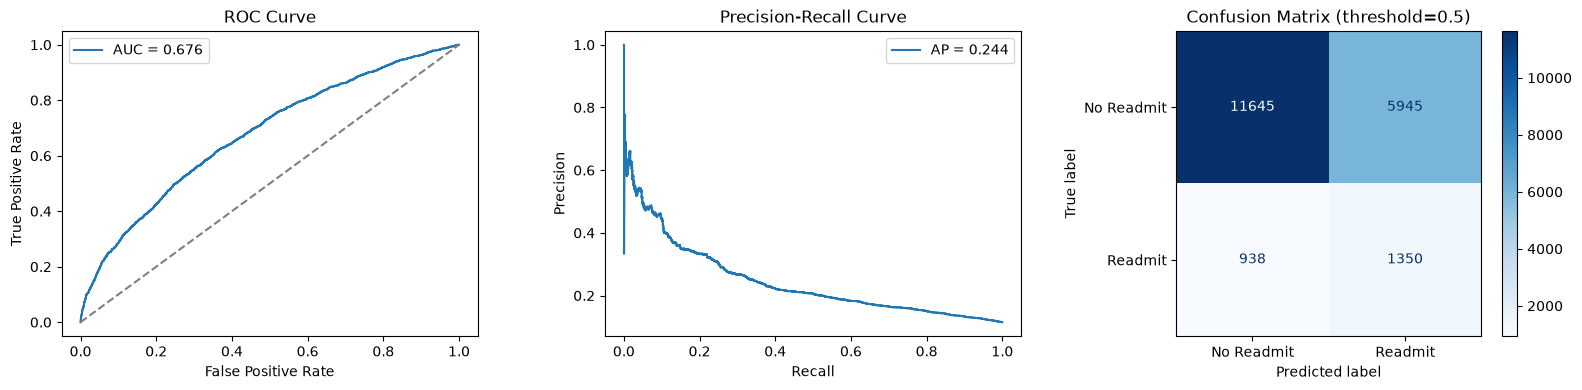

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,0.709698,0.270905,0.660932,0.194947,0.634279,0.298231,0.5
test,0.675939,0.244291,0.653738,0.185058,0.590035,0.281749,0.5


In [14]:
# retraining final model with the selected hyperparameters (from top_configs table) and evaluating on test set
best_params = {
    'subsample': 0.7,
    'n_estimators': 700,
    'min_child_weight': 15,
    'max_depth': 5,
    'learning_rate': 0.01,
    'colsample_bytree': 0.8,
}

print(best_params) 

xgb_tuned = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
)
xgb_tuned.fit(X_train, y_train)

# Evaluate the tuned model
y_train_pred_proba_tuned = xgb_tuned.predict_proba(X_train)
y_test_pred_proba_tuned = xgb_tuned.predict_proba(X_test)

train_metrics_tuned = compute_metrics(y_train, y_train_pred_proba_tuned)
test_metrics_tuned = evaluate_model(y_test, y_test_pred_proba_tuned)

pd.DataFrame([train_metrics_tuned, test_metrics_tuned], index=["train", "test"])

In [15]:
# Feature importance analysis - top 15 most importance features
importances_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_tuned.feature_importances_,
}).sort_values("importance", ascending=False)

importances_df.head(15)

,feature,importance
7,number_inpatient,0.068219
35,discharge_disposition_Discharged to home,0.059500
41,discharge_disposition_Discharged/transferred t...,0.032747
37,discharge_disposition_Discharged/transferred t...,0.017822
160,primary_diagnosis_category_musculoskeletal,0.015898
43,discharge_disposition_Discharged/transferred t...,0.014459
6,number_emergency,0.013319
164,primary_diagnosis_category_respiratory,0.011767
8,number_diagnoses,0.011767
45,discharge_disposition_Discharged/transferred t...,0.011691


### Feature Importance

The top 4 features consisted of number of past inpatient visits and various discharge outcomes which is consistent with previous model results. 

### Threshold Sweep

Similar analysis performed from the previous model notebooks to observe model potential when optimizing for threshold. 

In [16]:
from src.evaluate import threshold_sweep, plot_threshold_sweep

sweep_df = threshold_sweep(y_test, y_test_pred_proba_tuned)
sweep_df

,threshold,precision,recall,f1,accuracy
0,0.10,0.115102,1.000000,0.206442,0.115102
1,0.15,0.115183,1.000000,0.206573,0.115806
2,0.20,0.116034,0.994755,0.207825,0.127125
3,0.25,0.118619,0.982080,0.211672,0.158014
4,0.30,0.125065,0.952360,0.221095,0.227639
5,0.35,0.134093,0.895105,0.233244,0.322618
6,0.40,0.147439,0.811626,0.249546,0.438123
7,0.45,0.162842,0.713287,0.265150,0.544924
8,0.50,0.185058,0.590035,0.281749,0.653738
9,0.55,0.212749,0.453671,0.289661,0.743888


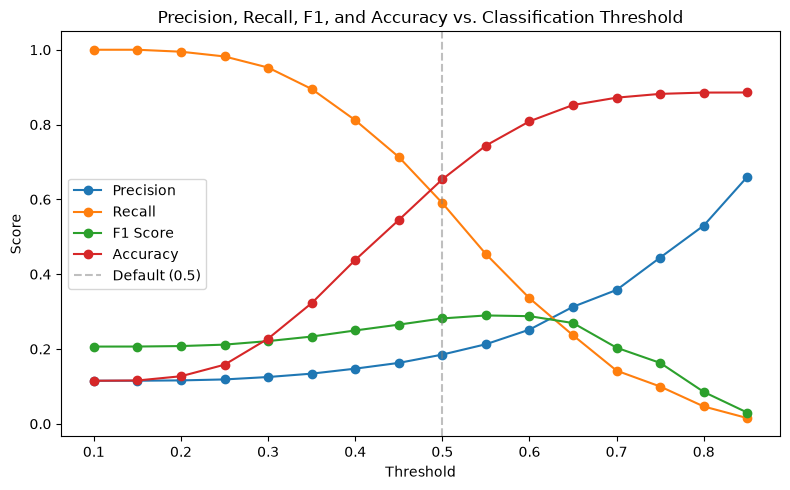

In [ ]:
plot_threshold_sweep(sweep_df)

### Threshold Sweep Results 

Results were similar to previous models, where the optimal threshold appears to be around the default 0.5 value. F1 score peaks at 0.55 at a value of 0.2897. This comes at the cost of recall which drops to ~0.454. Since recall should be prioritized (since we want to reduce false negatives), decreasing the threshold is prefered (threshold of 0.45-0.5). 

# Key Takeaways
- Baseline XGBoost model experienced noticeable overfitting (train PR-AUC of 0.415 vs. test PR-AUC of 0.221). Performance of the baseline was worse than the tuned random forest model. 
- After performing hyperparameter tuning, the final model improved performance to test PR-AUC of 0.244, while also reducing overfitting. This serves as the best performing model out of the 3 models tested. 
    - Previous iterations of XGBoost models that are not shared in this notebook had test PR-AUC results in the range of 0.240-0.248, suggesting a plateau in model perfomance.  
- Feature importance in this model adds additional confirmation to the importance of number of prior inpatient visits and discharge outcomes to predicting early readmission. 
- Threshold sweep agrees across all models that a threshold between 0.45-0.5 are optimal when prioritizing recall. 
